# RBP Classifier — ESM2-650M + Linear Head

Ternary classification: **TF** / **TSP** / **nonRBP**  
Frozen ESM2-650M embeddings → mean pool → trainable linear layer.

Pipeline:
1. Load processed FASTAs
2. Cluster-aware stratified train/val/test split
3. Extract & cache ESM2 embeddings
4. PCA exploration
5. Train linear classifier
6. Evaluate

In [1]:
import os
import subprocess
import tempfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

# ESM2-650M via HuggingFace transformers
from transformers import AutoModelForMaskedLM, AutoTokenizer

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# ESM2-650M is the chosen model: embedding-benchmark showed no significant gain
# from ESMC-6B or SaProt, so we use the smallest, dependency-light, seq-only PLM.
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
EMBED_CACHE = DATA_DIR / "embeddings_cache_esm2.pt"
USE_CACHE = False   # recompute embeddings every run; set True to reuse the cache

# Class ids match the older rbpdetect version: 0=nonRBP, 1=TF, 2=TSP.
LABEL2ID = {"nonRBP": 0, "TF": 1, "TSP": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
COLORS   = {"TF": "#e74c3c", "TSP": "#3498db", "nonRBP": "#2ecc71"}

SEED       = 42
BATCH_SIZE = 64
LR         = 1e-3
EPOCHS     = 50
CLUST_ID   = 0.3   # identity threshold for cluster-aware split
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# Select GPU with most free memory, fall back to CPU.
# ESM2-650M in bfloat16 is ~1.3 GB, so it fits comfortably anywhere.
if torch.cuda.is_available():
    free = [torch.cuda.mem_get_info(i)[0] for i in range(torch.cuda.device_count())]
    DEVICE = torch.device(f"cuda:{free.index(max(free))}")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}  ({torch.cuda.get_device_name(DEVICE) if DEVICE.type == 'cuda' else 'CPU'})")
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda:0  (NVIDIA GeForce RTX 5060 Ti)


## 1. Load Data

In [2]:
def parse_fasta(path: Path, label: str) -> list[dict]:
    records = []
    header, seq_parts = None, []
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if line.startswith(">"):
                if header:
                    records.append({"id": header.split()[0], "header": header,
                                    "sequence": "".join(seq_parts), "label": label})
                header, seq_parts = line[1:], []
            elif line:
                seq_parts.append(line)
    if header:
        records.append({"id": header.split()[0], "header": header,
                        "sequence": "".join(seq_parts), "label": label})
    return records

records = (
    parse_fasta(DATA_DIR / "tf.fasta",     "TF") +
    parse_fasta(DATA_DIR / "tsp.fasta",    "TSP") +
    parse_fasta(DATA_DIR / "nonrbp.fasta", "nonRBP")
)
df = pd.DataFrame(records)
df["label_id"] = df["label"].map(LABEL2ID)
df["seq_len"]  = df["sequence"].str.len()
print(df["label"].value_counts())
df.head(3)

label
nonRBP    1385
TSP        990
TF         778
Name: count, dtype: int64


,id,header,sequence,label,label_id,seq_len
0,YAO58174.1,YAO58174.1 TF product=TF_(gp38) phage=vB_EcoM_...,MADVQTRPDNDIFASSAGTGELLPFGDLARGWGATLGYSEGIPPME...,TF,1,444
1,YP_004934532.1,YP_004934532.1 TF product=TF_(g298) phage=φR1-...,MANLSRIAFVLRTIPNLNSEEITGIYPGELFLVGDKKAIFYKQGDG...,TF,1,704
2,XYO02678.1,XYO02678.1 TF product=TF_(ORF22) phage=vB_VpM-...,MATEKPDLTRVWASGAPEGNVVDPDTQIAGKVASGWVAEAPSFRHF...,TF,1,634


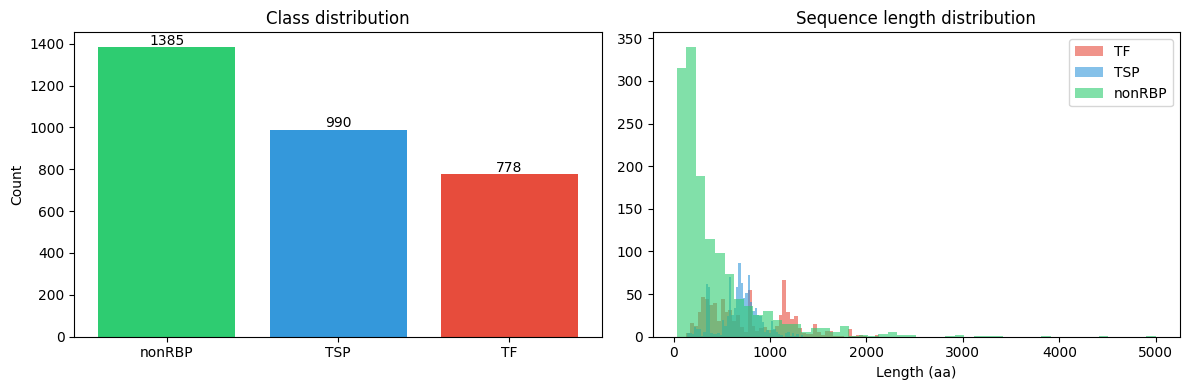

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
TF,778.0,776.9,419.7,129.0,417.2,674.0,1146.2,2129.0
TSP,990.0,672.6,211.2,141.0,579.2,688.0,792.0,1347.0
nonRBP,1385.0,418.3,476.6,33.0,138.0,250.0,504.0,5002.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df["label"].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[COLORS[l] for l in counts.index])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center")

# Sequence length distribution
for label, grp in df.groupby("label"):
    axes[1].hist(grp["seq_len"], bins=50, alpha=0.6,
                 label=label, color=COLORS[label])
axes[1].set_title("Sequence length distribution")
axes[1].set_xlabel("Length (aa)")
axes[1].legend()
plt.tight_layout()
plt.show()
df.groupby("label")["seq_len"].describe().round(1)

## 2. Cluster-aware Train / Val / Test Split

Run MMseqs2 on all sequences combined at 30% identity. Sequences in the same cluster are forced into the same split to prevent data leakage.

In [4]:
import shutil

def mmseqs_cluster_all(df: pd.DataFrame, min_id: float = 0.3, cov: float = 0.8) -> dict[str, str]:
    """Return {seq_id: cluster_rep} for all sequences."""
    if not shutil.which("mmseqs"):
        raise RuntimeError("mmseqs not in PATH")
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        fasta = tmp / "all.fasta"
        with open(fasta, "w") as f:
            for _, row in df.iterrows():
                f.write(f">{row['id']}\n{row['sequence']}\n")
        prefix = tmp / "clust"
        subprocess.run([
            "mmseqs", "easy-cluster",
            str(fasta), str(prefix), str(tmp / "mmseqs_tmp"),
            "--min-seq-id", str(min_id),
            "-c", str(cov), "--cov-mode", "0",
            "--cluster-mode", "2", "-v", "0",
        ], check=True)
        member_to_rep = {}
        with open(str(prefix) + "_cluster.tsv") as f:
            for line in f:
                rep, member = line.strip().split("\t")
                member_to_rep[member] = rep
    return member_to_rep


def cluster_aware_split(
    df: pd.DataFrame,
    member_to_rep: dict[str, str],
    val_frac: float = 0.15,
    test_frac: float = 0.15,
    seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    df = df.copy()
    df["cluster"] = df["id"].map(member_to_rep)

    # Build cluster-level info: dominant label + size
    clust_info = (
        df.groupby("cluster")["label"]
        .agg(lambda s: s.value_counts().index[0])  # dominant label
        .reset_index()
        .rename(columns={"label": "dominant_label"})
    )
    clust_info["size"] = df.groupby("cluster").size().values

    # Stratified shuffle split at cluster level
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(
        n_splits=1, test_size=val_frac + test_frac, random_state=seed
    )
    X = clust_info["cluster"].values
    y = clust_info["dominant_label"].values
    train_idx, holdout_idx = next(sss.split(X, y))

    holdout_info = clust_info.iloc[holdout_idx]
    sss2 = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_frac / (val_frac + test_frac),
        random_state=seed,
    )
    val_idx, test_idx = next(
        sss2.split(holdout_info["cluster"].values, holdout_info["dominant_label"].values)
    )

    train_clusts = set(clust_info.iloc[train_idx]["cluster"])
    val_clusts   = set(holdout_info.iloc[val_idx]["cluster"])
    test_clusts  = set(holdout_info.iloc[test_idx]["cluster"])

    def assign(row):
        c = row["cluster"]
        if c in train_clusts: return "train"
        if c in val_clusts:   return "val"
        return "test"

    df["split"] = df.apply(assign, axis=1)
    return df


print("Running MMseqs2 clustering on all sequences...")
member_to_rep = mmseqs_cluster_all(df, min_id=CLUST_ID)
df = cluster_aware_split(df, member_to_rep, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED)

print("\nSplit counts:")
print(df.groupby(["split", "label"]).size().unstack(fill_value=0))

Running MMseqs2 clustering on all sequences...



Split counts:
label   TF  TSP  nonRBP
split                  
test   102  115     208
train  601  725     969
val     75  150     208


## 3. Extract ESM2 Embeddings

Mean-pool over residue positions (excluding BOS/EOS tokens). Embeddings are cached to disk — skip extraction if cache exists.

In [5]:
plm_model = AutoModelForMaskedLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
).to(DEVICE).eval()
plm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

embed_dim = plm_model.config.hidden_size  # ESM2 config exposes hidden_size
print(f"Loaded {MODEL_NAME}")
print(f"Embedding dim: {embed_dim}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded facebook/esm2_t33_650M_UR50D
Embedding dim: 1280


In [6]:
@torch.inference_mode()
def embed_sequence(sequence: str) -> np.ndarray:
    inputs = plm_tokenizer([sequence], return_tensors="pt", padding=False)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    output = plm_model(**inputs, output_hidden_states=True)
    # hidden_states[-1]: (1, L+2, d) — BOS (CLS) at 0, EOS at -1
    emb = output.hidden_states[-1][0, 1:-1, :].float()
    return emb.mean(dim=0).cpu().numpy()


if USE_CACHE and EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE}")
    # weights_only=False: cache holds numpy arrays (not just tensors) and is a
    # local, self-produced artifact, so loading the pickle is safe here.
    cache  = torch.load(EMBED_CACHE, weights_only=False)
    id2emb = dict(zip(cache["ids"], cache["embeddings"]))
else:
    print(f"Extracting embeddings for {len(df)} sequences...")
    ids, embeddings = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        ids.append(row["id"])
        embeddings.append(embed_sequence(row["sequence"]))
    embeddings_np = np.stack(embeddings)
    torch.save({"ids": ids, "embeddings": embeddings_np}, EMBED_CACHE)
    id2emb = dict(zip(ids, embeddings_np))
    print(f"Saved to {EMBED_CACHE}")

df["embedding"] = df["id"].map(id2emb)
print(f"Embedding shape: {df['embedding'].iloc[0].shape}")

Extracting embeddings for 3153 sequences...


  0%|          | 0/3153 [00:00<?, ?it/s]

Saved to ../data/embeddings_cache_esm2.pt
Embedding shape: (1280,)


## 4. PCA Exploration

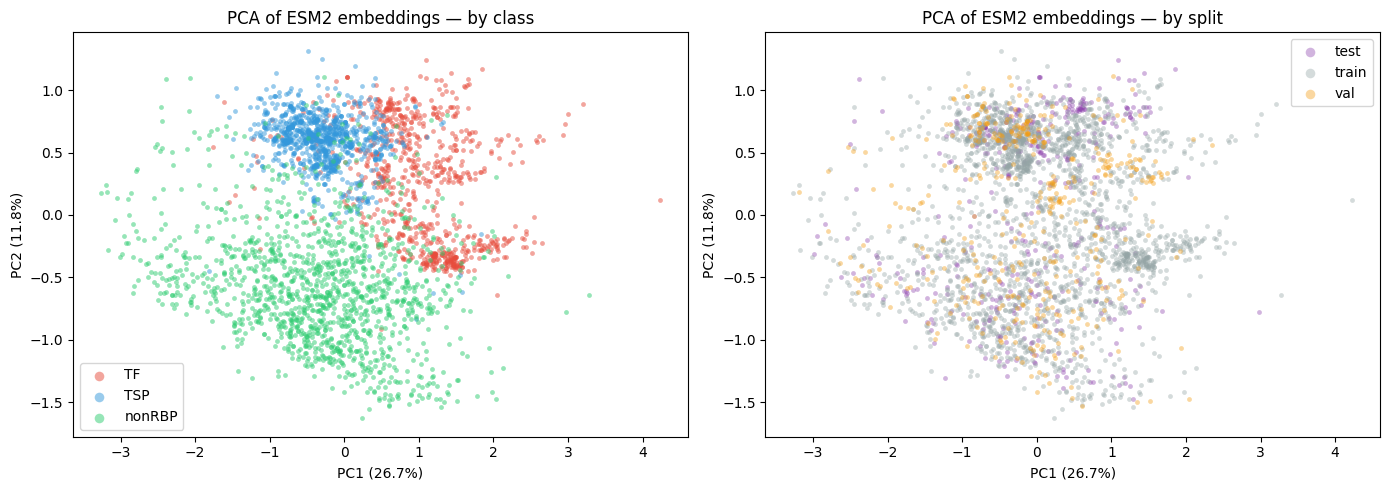

In [7]:
X_all = np.stack(df["embedding"].values)
pca   = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_all)
var   = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2, colored by class
for label, grp in df.groupby("label"):
    idx = grp.index
    axes[0].scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        c=COLORS[label], label=label, alpha=0.5, s=12, linewidths=0,
    )
axes[0].set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
axes[0].set_title("PCA of ESM2 embeddings — by class")
axes[0].legend(markerscale=2)

# Same plot colored by split
split_colors = {"train": "#95a5a6", "val": "#f39c12", "test": "#8e44ad"}
for split, grp in df.groupby("split"):
    idx = grp.index
    axes[1].scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        c=split_colors[split], label=split, alpha=0.4, s=12, linewidths=0,
    )
axes[1].set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
axes[1].set_title("PCA of ESM2 embeddings — by split")
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig(DATA_DIR / "pca_embeddings_esm2.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Dataset & DataLoader

In [8]:
class EmbeddingDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.X = torch.tensor(np.stack(df["embedding"].values), dtype=torch.float32)
        self.y = torch.tensor(df["label_id"].values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_ds = EmbeddingDataset(df[df["split"] == "train"])
val_ds   = EmbeddingDataset(df[df["split"] == "val"])
test_ds  = EmbeddingDataset(df[df["split"] == "test"])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

# Class weights to handle imbalance
train_labels = df[df["split"] == "train"]["label_id"].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(LABEL2ID)),
    y=train_labels,
)
print(f"Class weights: { {ID2LABEL[i]: round(w, 3) for i, w in enumerate(class_weights)} }")

Train: 2295  Val: 433  Test: 425
Class weights: {'nonRBP': np.float64(0.789), 'TF': np.float64(1.273), 'TSP': np.float64(1.055)}


## 6. Model — Linear Classifier

In [9]:
class LinearClassifier(nn.Module):
    def __init__(self, in_dim: int, n_classes: int):
        super().__init__()
        self.head = nn.Linear(in_dim, n_classes)

    def forward(self, x):
        return self.head(x)


model = LinearClassifier(in_dim=embed_dim, n_classes=len(LABEL2ID)).to(DEVICE)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print(model)

LinearClassifier(
  (head): Linear(in_features=1280, out_features=3, bias=True)
)


## 7. Training

In [10]:
def run_epoch(loader, model, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss   = criterion(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state = 0.0, None

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(val_loader,   model, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.3f} | "
              f"vl_loss {vl_loss:.4f} vl_acc {vl_acc:.3f}")

print(f"\nBest val acc: {best_val_acc:.3f}")
model.load_state_dict(best_state)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  10 | tr_loss 0.1531 tr_acc 0.969 | vl_loss 0.1733 vl_acc 0.961


Epoch  20 | tr_loss 0.1046 tr_acc 0.974 | vl_loss 0.1325 vl_acc 0.970


Epoch  30 | tr_loss 0.0880 tr_acc 0.976 | vl_loss 0.1194 vl_acc 0.972


Epoch  40 | tr_loss 0.0824 tr_acc 0.976 | vl_loss 0.1147 vl_acc 0.972


Epoch  50 | tr_loss 0.0817 tr_acc 0.977 | vl_loss 0.1139 vl_acc 0.972

Best val acc: 0.972


<All keys matched successfully>

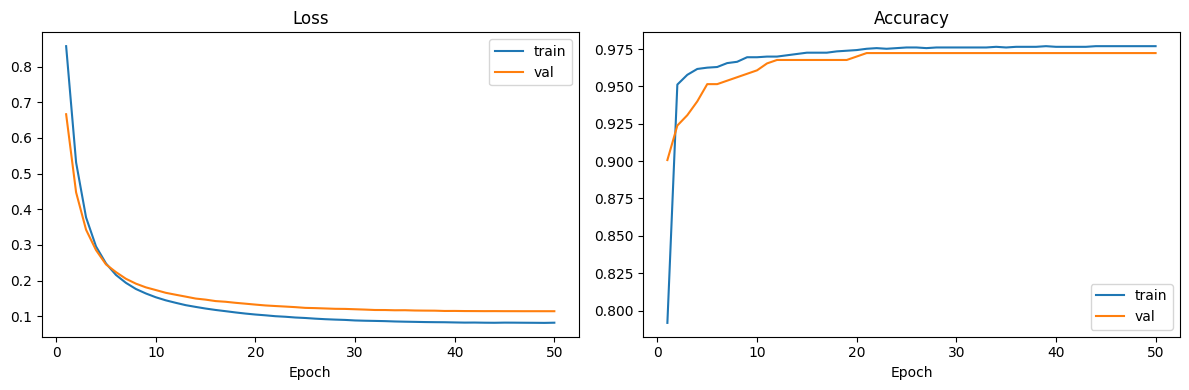

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Evaluation on Test Set

              precision    recall  f1-score   support

      nonRBP       1.00      0.96      0.98       208
          TF       0.95      0.98      0.97       102
         TSP       0.96      0.99      0.97       115

    accuracy                           0.97       425
   macro avg       0.97      0.98      0.97       425
weighted avg       0.97      0.97      0.97       425



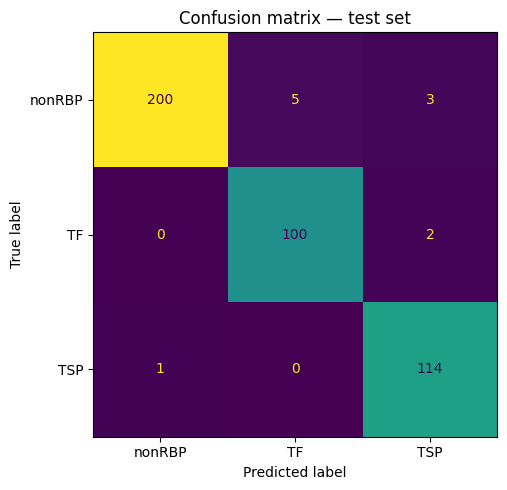

In [12]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        preds = model(X.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

label_names = [ID2LABEL[i] for i in range(len(LABEL2ID))]
print(classification_report(all_labels, all_preds, target_names=label_names))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, colorbar=False)
ax.set_title("Confusion matrix — test set")
plt.tight_layout(); plt.show()

In [13]:
# Persist held-out test predictions + the split so the trained model can be
# benchmarked outside the notebook (scripts/benchmark_trained_model.py) on the
# exact proteins it never saw during training.
BENCH_RESULTS = Path("../benchmarks/results")
BENCH_RESULTS.mkdir(parents=True, exist_ok=True)

test_df = df[df["split"] == "test"].reset_index(drop=True)
model.eval()
with torch.no_grad():
    X_test = torch.tensor(np.stack(test_df["embedding"].values), dtype=torch.float32, device=DEVICE)
    probs = torch.softmax(model(X_test), dim=1).cpu().numpy()
pred_ids = probs.argmax(1)

pred_df = pd.DataFrame({
    "id": test_df["id"],
    "cluster": test_df["cluster"],
    "label": test_df["label"],
    "prediction": [ID2LABEL[i] for i in pred_ids],
})
for class_id in range(len(LABEL2ID)):
    pred_df[f"prob_{ID2LABEL[class_id]}"] = probs[:, class_id]

pred_df.to_csv(BENCH_RESULTS / "trained_model_test_predictions.tsv", sep="\t", index=False)
df[["id", "label", "cluster", "split"]].to_csv(BENCH_RESULTS / "trained_model_split.tsv", sep="\t", index=False)
print(f"Wrote {len(pred_df)} test predictions + split to {BENCH_RESULTS}")

Wrote 425 test predictions + split to ../benchmarks/results


## 9. Save Model

In [14]:
checkpoint = {
    "model_state_dict": best_state,
    "label2id": LABEL2ID,
    "id2label": ID2LABEL,
    "embed_dim": embed_dim,
    "plm_model_name": MODEL_NAME,
    "best_val_acc": best_val_acc,
}
model_slug = MODEL_NAME.replace("/", "_")
save_path = MODELS_DIR / f"rbpdetect2_linear_{model_slug}.pt"
torch.save(checkpoint, save_path)
print(f"Saved to {save_path}")

Saved to ../models/rbpdetect2_linear_facebook_esm2_t33_650M_UR50D.pt
